# Which network is actually right, and where does it go wrong?

This notebook produces `Plots/model_error_rates_val.pdf`, saved into the
manuscript as `final_figures/model_error_rates_val_half.pdf` (Fig. 19, App. F 5
"Contribution of the $X$ and $Z$ measurement bases to classification"). The `_val_half` suffix is added by hand at
release time, since the file on disk always carries the plain `_{SPLIT}` name; it records
that this copy was produced with `XZ_SNAPSHOTS = "half"` below (see that cell). The
companion `model_error_counts_val.pdf` this notebook also writes is a diagnostic, not used
in the manuscript.

`Figures5_6_combined_pipeline.ipynb` draws a per-time-point error-rate histogram for the *closed-form
decision boundaries* (plane vs square) fitted in the latent / correlator space of **one**
run. That figure measures how well an equation reproduces the network.

This notebook asks the prior question: **how well does each network itself classify?** The
error rate here is the trained model's prediction against the **ground-truth partition
label**, resolved per time point: no boundary fitting, no correlators, nothing fitted in
this notebook at all.

### Reading the three panels

- **(a)** the Ising model from the main text (Figs. 4-6), a single representative seed.
- **(b)** the XY model from the main text, likewise a single representative seed, on its
  native (unmatched) acquisition grid. This is the model whose overall validation accuracy
  is quoted in the main text; the `XY_Z_UM`/`XY_X_UM` selectors above `XY_XZ_UM` build the
  same panel from the $Z$-only or $X$-only bases instead, and are kept, commented out, as a
  diagnostic against panel (c)'s matched comparison rather than something the manuscript
  shows.
- **(c)** the dedicated $X$/$Z$/$XZ$ ablation of App. F (`app:separate_X_Z_training`): the
  same three bases retrained on a snapshot-count-matched setup so their accuracies are
  directly comparable, averaged over 5 seeds each. This panel is where the manuscript's
  quoted accuracies for the separate bases come from (flagged again at the cell that prints
  them).

Panels (b) and (c) share the same combined-basis model architecture and $\lambda_{\max}$;
only the training data differs, native vs. matched. Every model is chosen by its own
selector cell below, so any one of them can be repointed at a different $\lambda_{\max}$ or
partition without touching the rest of the notebook.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE

import warnings
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from tetriscnn.datasets import create_datasets
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import AttrDict, DEVICE, load_json

from tetriscnn.colors import COLORS

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Shared configuration

`SPLIT` is the one global choice with teeth. Nothing in this notebook is *fitted*, so the
train split is not contaminated the way it is in `Figures5_6_combined_pipeline.ipynb`, but it is
still the data the network was optimised on, so `"val"` is the honest default and `"train"`
is what to use if you want the figure to show the same snapshots the training curves did.

In [2]:
SPLIT = "val"            # "val" (held out) or "train"

# Panel (b), XZ bar only: which snapshot-count-matched XZ training set to read.
# An XZ training example PAIRS one X-basis and one Z-basis snapshot, so matching XZ
# to the X/Z arms by EXAMPLE count ("equal") lets it consume ~2x their raw
# snapshots; matching by RAW-SNAPSHOT budget ("half") gives it
# min(n_X(t), n_Z(t)) // 2 paired examples instead (half the examples, ~equal raw
# snapshots). X and Z (panel-b cells b1/b2) are the same runs either way -- only the
# XZ arm was retrained. "equal" is the default and matches Figures5_6_combined_pipeline /
# Figure6. See Plots_data/README.md for both setups.
XZ_SNAPSHOTS = "half"   # "equal" | "half"

# What the bars measure. "percent" / "fraction" are the same quantity -- the per-time-
# point error RATE -- and "count" is the raw number of misclassified snapshots.
#
# The two answer different questions and neither is redundant. A rate is comparable
# ACROSS time points; a count is not, but it is the only one that says how much data a
# bar rests on. Under the even split the sample counts vary by 3-4x between time points
# (and by 20x for XY_Z), so a tall rate bar can be a handful of snapshots: the Ising
# model is 0.86% wrong overall yet 18.9% wrong at t = 1.2 us, which is 17 errors out of
# the 90 snapshots that time point contributes. Only the count panel shows that.
Y_MODE = "percent"       # "percent" | "fraction" | "count"

# Bottom panel: three series on one axes.
#
# "dodged" is the DEFAULT, which departs from the two-series histogram in
# Figures5_6_combined_pipeline. Overlaying works for two series because the shorter one reads as
# sitting in front of the taller. With three it reads as a STACK: at t=0 the XY_X bar is
# 34% and the other two are ~4%, and drawn on top of it they look like the bottom two
# segments of a 34% total rather than two independent 4% bars.
#
# "layered" restores the overlaid style anyway -- tallest behind, occlusions counted and
# reported -- if matching the companion figure matters more than that ambiguity.
XY_PANEL_STYLE = "layered"

OUTDIR = Path("Plots")
OUTDIR.mkdir(exist_ok=True)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
GOLDEN = (1 + np.sqrt(5)) / 2

try:
    plt.style.use(PAPER_MPLSTYLE)
except Exception as exc:                       # LaTeX not reachable from this kernel
    print(f"paper.mplstyle unavailable ({exc}); falling back to mathtext")
    plt.rcParams["text.usetex"] = False

## Model selectors

One cell per model. Each names a **run-folder template** (a `path_template` with a
`{seed}` placeholder plus the `seeds` tuple it is evaluated over), since every bar in this
notebook is a mean ± std across 5 seeds, not one run. `seed_path(m, s)` fills in the
placeholder for one seed; `load_run_seeds(m, split)` loads all of them.

**Panel (b), unmatched.** The three `*_UM` selectors point at the pre-matching runs, read
off their `lambdamax_3` sweep folders and copied into `Plots_data/` as
`XY_{Z}_..._seed{s}_p4` (Z, `partition_4`, native 21-time grid) and `XY_{X,XZ}_..._seed{s}_p2`
(X and XZ, `partition_2`, native 13-time grid). Same $\lambda_{\max}$, same 5 seeds, same
C4-equivariant `smallkernels` architecture as everything else. Only the dataset differs: no
`filter_t_values`, no `samples_per_pt_cap`, so Z keeps its ~1.9x-larger training set and its
own 587.5ns threshold.

**Panel (c), matched.** The three plain selectors point at `scripts/matched_basis_survey.py`'s
output: X, Z and XZ retrained on the same 13 time points, the same per-timepoint snapshot cap
(`min(n_X(t), n_Z(t))`), and the same `partition_2` / 625ns threshold, so the panel compares
three genuinely equal-footing datasets. **`XZ_SNAPSHOTS`** (shared-configuration cell) then
switches the panel-(c) XZ bar between `"equal"` (`min(n_X(t), n_Z(t))` paired examples, the
same example count as the X/Z arms) and `"half"` (`min(n_X(t), n_Z(t)) // 2`, half the
paired examples, so the same *raw*-snapshot budget, since an XZ example bundles one X- and
one Z-basis snapshot). See `Plots_data/README.md` and App. F 5 of the manuscript.

The Ising selector is unaffected (single dataset, nothing to match against). The Ising and
matched-XZ (`"equal"`) defaults are exactly the two runs `Figure6.ipynb` draws (there,
a single representative seed); the other XY defaults have no such precedent and match that
choice of $\lambda_{\max}$.

In [3]:
# --- (a) Ising -----------------------------------------------------------------------
# available: lambdamax_{-3..5}/seed_{0,42,43,44,45,46,69,137,420,2137,...}/partition_2
# Bars are mean +/- std over these 5 seeds (see the shared-configuration cell) -- all
# 5 are copied into Plots_data for this notebook specifically.
ISING = dict(
    label="Ising",
    path_template=Path("Plots_data/Ising_C4_smallkernels_lam3_seed{seed}_p2"),
    # seeds=(42, 43, 44, 45, 46),
    seeds=(42),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)

In [4]:
# --- (c1) XY, Z basis -- panel (c), snapshot-count-matched, mean +/- std over 5 seeds
# available: lambdamax_3/seed_{42..46}/partition_2 (matched runs are lambdamax_3 only)
XY_Z = dict(
    label=r"XY, $Z$",
    path_template=Path("Plots_data/XY_Z_C4_smallkernels_lam3_seed{seed}_p2_matched"),
    seeds=(42, 43, 44, 45, 46),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)

In [5]:
# --- (c2) XY, X basis -- panel (c), snapshot-count-matched, mean +/- std over 5 seeds
# available: lambdamax_3/seed_{42..46}/partition_2 (matched runs are lambdamax_3 only)
XY_X = dict(
    label=r"XY, $X$",
    path_template=Path("Plots_data/XY_X_C4_smallkernels_lam3_seed{seed}_p2_matched"),
    seeds=(42, 43, 44, 45, 46),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)

In [6]:
# --- (c3) XY, both bases -- panel (c), snapshot-count-matched, mean +/- std over 5 seeds
# available: lambdamax_3/seed_{42..46}/partition_2 (matched runs are lambdamax_3 only)
# XZ_SNAPSHOTS (shared-configuration cell) picks which matched XZ training set to read:
#   "equal" -> Plots_data/..._p2_matched         (min(n_X(t), n_Z(t)) paired examples;
#                                                 same EXAMPLE count as the X/Z arms)
#   "half"  -> Plots_data/..._p2_matched_xzhalf  (min(n_X(t), n_Z(t)) // 2 paired
#                                                 examples; ~equal RAW-snapshot budget)
_XZ_SUFFIX = {"equal": "_matched", "half": "_matched_xzhalf"}[XZ_SNAPSHOTS]
XY_XZ = dict(
    label=r"XY, $XZ$",
    path_template=Path(
        f"Plots_data/XY_XZ_C4_smallkernels_lam3_seed{{seed}}_p2{_XZ_SUFFIX}"),
    seeds=(42, 43, 44, 45, 46),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)

In [7]:
# --- PANEL (b): XY, all three bases, UNMATCHED (native acquisition grids) ------------
# The pre-matching runs, straight from each basis's own `lambdamax_3` sweep and copied
# into Plots_data. Same lambda_max, same 5 seeds, same C4-smallkernels architecture as
# panel (c) -- the ONLY difference is the dataset:
#   * Z  -> partition_4 / 587.5ns on its native 21-time grid, ~1.9x more snapshots
#   * X  -> partition_2 / 625ns on its native 13-time grid
#   * XZ -> partition_2 / 625ns, min(n_X, n_Z) pairing (XZ is barely changed by matching)
# Grouped in one cell because this is a fixed historical baseline, not something to
# repoint; edit panel (c)'s selectors above for that.
XY_Z_UM = dict(
    label=r"XY, $Z$",
    path_template=Path("Plots_data/XY_Z_C4_smallkernels_lam3_seed{seed}_p4"),
    # seeds=(42, 43, 44, 45, 46),
    seeds=(46),
    run_template="lambdamax_3/seed_{seed}/partition_4",
)
XY_X_UM = dict(
    label=r"XY, $X$",
    path_template=Path("Plots_data/XY_X_C4_smallkernels_lam3_seed{seed}_p2"),
    # seeds=(42, 43, 44, 45, 46),
    seeds=(46),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)
XY_XZ_UM = dict(
    label=r"XY, $XZ$",
    path_template=Path("Plots_data/XY_XZ_C4_smallkernels_lam3_seed{seed}_p2"),
    # seeds=(42, 43, 44, 45, 46),
    seeds=(46),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)

In [8]:
# Assembled here so the selector cells above stay independent of the panel layout.
TOP = OrderedDict([("ising", ISING)])
# MIDDLE = OrderedDict([("xy_z_um", XY_Z_UM), ("xy_x_um", XY_X_UM), ("xy_xz_um", XY_XZ_UM)])
MIDDLE = OrderedDict([("xy_xz_um", XY_XZ_UM)])
BOTTOM = OrderedDict([("xy_z", XY_Z), ("xy_x", XY_X), ("xy_xz", XY_XZ)])
MODELS = OrderedDict(
    list(TOP.items()) + list(MIDDLE.items()) + list(BOTTOM.items()))

# Normalize `seeds`: writing a single seed as `seeds=(42)` is a common trap -- Python
# parses that as the bare int 42, not a 1-tuple, since a 1-tuple needs the trailing
# comma `(42,)`. Every consumer below just does `for s in m["seeds"]`, so wrap a bare
# int here, once, rather than have that bite (or be worked around) in five different
# places downstream.
for m in MODELS.values():
    if isinstance(m["seeds"], int):
        m["seeds"] = (m["seeds"],)

# key -> panel letter, so every downstream cell resolves the panel the same way.
PANEL_OF = {**{k: "a" for k in TOP},
            **{k: "b" for k in MIDDLE},
            **{k: "c" for k in BOTTOM}}


def seed_path(m, seed):
    """The run folder for one seed of model dict `m`."""
    return Path(str(m["path_template"]).format(seed=seed))


missing = []
for key, m in MODELS.items():
    for s in m["seeds"]:
        p = seed_path(m, s)
        ok = (p / "net1.pt").exists()
        print(f"{key:>8} seed_{s}  {'OK ' if ok else 'MISSING'}  {p}")
        if not ok:
            missing.append((key, s))

if missing:
    raise FileNotFoundError(f"no net1.pt for: {missing}")

   ising seed_42  OK   Plots_data/Ising_C4_smallkernels_lam3_seed42_p2
xy_xz_um seed_46  OK   Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
    xy_z seed_42  OK   Plots_data/XY_Z_C4_smallkernels_lam3_seed42_p2_matched
    xy_z seed_43  OK   Plots_data/XY_Z_C4_smallkernels_lam3_seed43_p2_matched
    xy_z seed_44  OK   Plots_data/XY_Z_C4_smallkernels_lam3_seed44_p2_matched
    xy_z seed_45  OK   Plots_data/XY_Z_C4_smallkernels_lam3_seed45_p2_matched
    xy_z seed_46  OK   Plots_data/XY_Z_C4_smallkernels_lam3_seed46_p2_matched
    xy_x seed_42  OK   Plots_data/XY_X_C4_smallkernels_lam3_seed42_p2_matched
    xy_x seed_43  OK   Plots_data/XY_X_C4_smallkernels_lam3_seed43_p2_matched
    xy_x seed_44  OK   Plots_data/XY_X_C4_smallkernels_lam3_seed44_p2_matched
    xy_x seed_45  OK   Plots_data/XY_X_C4_smallkernels_lam3_seed45_p2_matched
    xy_x seed_46  OK   Plots_data/XY_X_C4_smallkernels_lam3_seed46_p2_matched
   xy_xz seed_42  OK   Plots_data/XY_XZ_C4_smallkernels_lam3_seed42_p2_matched

In [9]:
# In the full logs/ tree this cell browsed every recorded lambda_max / seed /
# partition for each model, ranked by recorded val accuracy, as a guide when
# editing a selector above. The release ships only the selected runs (in
# Plots_data/, 5 seeds per model), so the browser has nothing else to enumerate.
for key, m in MODELS.items():
    print(f"{key:>8}  ({PANEL_OF[key]})  {m['run_template']}  "
          f"seeds={list(m['seeds'])}  ->  {m['path_template']}")

   ising  (a)  lambdamax_3/seed_{seed}/partition_2  seeds=[42]  ->  Plots_data/Ising_C4_smallkernels_lam3_seed{seed}_p2
xy_xz_um  (b)  lambdamax_3/seed_{seed}/partition_2  seeds=[46]  ->  Plots_data/XY_XZ_C4_smallkernels_lam3_seed{seed}_p2
    xy_z  (c)  lambdamax_3/seed_{seed}/partition_2  seeds=[42, 43, 44, 45, 46]  ->  Plots_data/XY_Z_C4_smallkernels_lam3_seed{seed}_p2_matched
    xy_x  (c)  lambdamax_3/seed_{seed}/partition_2  seeds=[42, 43, 44, 45, 46]  ->  Plots_data/XY_X_C4_smallkernels_lam3_seed{seed}_p2_matched
   xy_xz  (c)  lambdamax_3/seed_{seed}/partition_2  seeds=[42, 43, 44, 45, 46]  ->  Plots_data/XY_XZ_C4_smallkernels_lam3_seed{seed}_p2_matched_xzhalf


## Load the runs

`load_run` is `Figures5_6_combined_pipeline.ipynb`'s loader with one addition: it also returns
`y_true`, the ground-truth class. For a `partition` task `dataset.labels` is one-hot, so
the class is its `argmax`, and it is constant within a time point (the partition is a
threshold on $t$), which is what makes a per-time-point error rate well defined.

`load_run_seeds` calls it once per seed of a model, so `DATA[key]` below is a **list of
5 per-seed result dicts**, not one dict: everything downstream (error rates, tables,
provenance) aggregates over that list rather than reading a single run.

In [10]:
def load_run(run_folder: Path, split: str = "val"):
    """Config + weights from a run folder, with one split pushed through the net."""
    cf = AttrDict()
    cf.update(load_json(str(run_folder), "config.json"))

    # Legacy runs recorded kernels without a stride entry.
    for k in range(len(cf.kernels)):
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    # Point the config at where it was LOADED from, not where it was first saved.
    cf.logdir = cf.seed_folder = str(run_folder)
    cf.return_all_data = False

    train_ds, val_ds = create_datasets(cf)
    dataset = {"train": train_ds, "val": val_ds}[split]

    net1 = ShapeAdaptiveConvNet(
        in_channels=dataset[0][0].shape[0],
        kernels=cf.kernels,
        equivariant=cf.equivariant,
        hidden_size=cf.hidden_size,
        init=cf.init,
        device=DEVICE,
    ).to(DEVICE)
    net2 = SmallModel(
        [len(cf.kernels), 32, 16, dataset.output_dim], device=DEVICE
    ).to(DEVICE)
    net1.load_state_dict(torch.load(run_folder / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(run_folder / "net2.pt", map_location=DEVICE))
    net1.eval()
    net2.eval()

    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            z = net1(x)
            out = net2(z)

    labels = dataset.labels.detach().cpu().numpy()
    if labels.ndim != 2 or labels.shape[1] < 2:
        raise ValueError(
            f"{run_folder}: expected one-hot labels from a discrete-label task, got "
            f"shape {labels.shape} (task={cf.task}). This notebook scores CLASSES.")

    return {
        "cf": cf, "path": run_folder, "split": split,
        "z": z.cpu().numpy(), "out": out.cpu().numpy(),
        "y_pred": out.cpu().numpy().argmax(axis=1),
        "y_true": labels.argmax(axis=1),
        "times": dataset.times.detach().cpu().numpy(),
    }

In [11]:
def load_run_seeds(m, split):
    """load_run() for every seed of model dict `m`, in seed order.

    Returns a plain list (not keyed by seed) since everything downstream just needs
    "the 5 runs of this model" to aggregate over -- `m["seeds"]` is the seed key
    when one is needed (e.g. the provenance table).
    """
    return [load_run(seed_path(m, s), split) for s in m["seeds"]]

This cell trains nothing; it loads every selected run and prints one summary line per
model. These are the numbers quoted in the manuscript: Ising (panel a) $99.14\%$, the XY
main-text model (panel b) $93.54\%$, and the matched ablation (panel c) $91.19\%$ ($Z$
alone), $70.28\%$ ($X$ alone), $93.07\%$ (combined $XZ$, `XZ_SNAPSHOTS = "half"`). Panels
(a) and (b) report a single seed's accuracy (matching the specific run shown in the main
text); panel (c) reports the mean over 5 seeds, consistent with the "five random
initializations" of `app:separate_X_Z_training`.


In [12]:
DATA = {}
for key, m in MODELS.items():
    DATA[key] = load_run_seeds(m, SPLIT)
    accs = np.array([float((d["y_pred"] == d["y_true"]).mean()) for d in DATA[key]])
    d0 = DATA[key][0]
    n_seeds = len(m["seeds"])
    # std across seeds needs >= 2 seeds; with one, print a bare point estimate rather
    # than a fabricated "+/-0.0000" (and rather than let ddof=1 on n=1 warn/NaN).
    acc_sd = accs.std(ddof=1) if n_seeds > 1 else None
    acc_str = f"{accs.mean():.4f}+-{acc_sd:.4f}" if acc_sd is not None else f"{accs.mean():.4f}"
    err_str = (f"{1 - accs.mean():.4f}+-{acc_sd:.4f}" if acc_sd is not None
               else f"{1 - accs.mean():.4f}")
    print(f"({PANEL_OF[key]}) {key:>8}  {d0['cf'].dataset:<14} "
          f"partition={d0['cf'].partition_index} "
          f"lam={d0['cf'].lam}  n={len(d0['y_true']):>6}  "
          f"times={len(np.unique(d0['times'])):>3}  "
          f"acc={acc_str}  "
          f"err={err_str}  ({n_seeds} seed{'s' if n_seeds != 1 else ''})")


 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples


times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])

Using C4-equivariant convolutional branches.


(a)    ising  Paris_Ising    partition=2 lam=3  n=  6282  times= 28  acc=0.9914  err=0.0086  (1 seed)



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.


(b) xy_xz_um  Paris_XY_XZ    partition=2 lam=3  n=  4347  times= 13  acc=0.9354  err=0.0646  (1 seed)
directory:  <repo>/datasets/experimental/XY/6x7_atoms_Z_ferro_video_15MHz_tau0p3_16032022_7_0_defects_0_holes


...


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] Applying per-timepoint cap dict over 13 time points (of 13 requested): {0.0: 888, 250.0: 878, 500.0: 876, 750.0: 528, 1000.0: 500, 1250.0: 497, 1500.0: 421, 1750.0: 233, 2000.0: 1287, 2500.0: 296, 3000.0: 398, 4000.0: 185, 6000.0: 246}
[Even Split] LBC class distribution after cap: class 0=2642, class 1=4591
[Even Split] After per-time-point 70/30 split: 5057 train, 2176 val samples
times shape: 5057, labels shape: torch.Size([5057])
times shape: 2176, labels shape: torch.Size([2176])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] Applying per-timepoint cap dict over 13 time points (of 13 requested): {0.0: 888, 250.0: 878, 500.0: 876, 750.0: 528, 1000.0: 500, 1250.0: 497, 1500.0: 421, 1750.0: 233, 2000.0: 1287, 2500.0: 296, 3000.0: 398, 4000.0: 185, 6000.0: 246}
[Even Split] LBC class distribution after cap: class 0=2642, class 1=4591
[Even Split] After per-time-point 70/30 split: 5057 train, 2176 val samples
times shape: 5057, labels shape: torch.Size([5057])
times shape: 2176, labels shape: torch.Size([2176])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] Applying per-timepoint cap dict over 13 time points (of 13 requested): {0.0: 888, 250.0: 878, 500.0: 876, 750.0: 528, 1000.0: 500, 1250.0: 497, 1500.0: 421, 1750.0: 233, 2000.0: 1287, 2500.0: 296, 3000.0: 398, 4000.0: 185, 6000.0: 246}
[Even Split] LBC class distribution after cap: class 0=2642, class 1=4591
[Even Split] After per-time-point 70/30 split: 5057 train, 2176 val samples
times shape: 5057, labels shape: torch.Size([5057])
times shape: 2176, labels shape: torch.Size([2176])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] Applying per-timepoint cap dict over 13 time points (of 13 requested): {0.0: 888, 250.0: 878, 500.0: 876, 750.0: 528, 1000.0: 500, 1250.0: 497, 1500.0: 421, 1750.0: 233, 2000.0: 1287, 2500.0: 296, 3000.0: 398, 4000.0: 185, 6000.0: 246}
[Even Split] LBC class distribution after cap: class 0=2642, class 1=4591
[Even Split] After per-time-point 70/30 split: 5057 train, 2176 val samples
times shape: 5057, labels shape: torch.Size([5057])
times shape: 2176, labels shape: torch.Size([2176])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] Applying per-timepoint cap dict over 13 time points (of 13 requested): {0.0: 888, 250.0: 878, 500.0: 876, 750.0: 528, 1000.0: 500, 1250.0: 497, 1500.0: 421, 1750.0: 233, 2000.0: 1287, 2500.0: 296, 3000.0: 398, 4000.0: 185, 6000.0: 246}
[Even Split] LBC class distribution after cap: class 0=2642, class 1=4591
[Even Split] After per-time-point 70/30 split: 5057 train, 2176 val samples
times shape: 5057, labels shape: torch.Size([5057])
times shape: 2176, labels shape: torch.Size([2176])

Using C4-equivariant convolutional branches.
(c)    xy_xz  Paris_XY_XZ    partition=2 lam=3  n=  2176  times= 13  acc=0.9307+-0.0004  err=0.0693+-0.0004  (5 seeds)


## Error rate by time point

`error_by_time` is the per-seed measurement: the mean of a boolean per-sample flag,
grouped by time. `error_stats_by_time` then takes the **mean and std across the 5
seeds** of one model, time point by time point, valid because the 5 seeds of a model
share the exact same train/val split (verified below), so only the trained weights
differ, not which snapshots landed in which time point. A time point with no samples in
this split returns `nan` rather than `0.0`: a missing bar and a bar of height zero mean
opposite things.

Each panel's XY runs are separate trainings on separate datasets, so their time grids are
not guaranteed to coincide (though each model's own 5 seeds do coincide with one another).
Panels (b) and (c) are therefore each indexed by the **union** of their three grids
(`MIDDLE_TIMES`, `BOTTOM_TIMES`). For the matched panel (c) that union is the shared
13-point grid. For the unmatched panel (b) it is Z's native 21-point grid: X and XZ have
bars only at the 13 points they share with it, and `nan` (a gap, not a zero) at the other
8, which is itself the visual statement that the three were never on the same task.

In [13]:
def error_by_time(d, all_times):
    """Per-time-point misclassification rate for ONE seed; nan where the split has no samples."""
    t, wrong = d["times"], d["y_pred"] != d["y_true"]
    return np.array([wrong[t == tt].mean() if np.any(t == tt) else np.nan
                     for tt in all_times])


def counts_by_time(d, all_times):
    t = d["times"]
    return np.array([int((t == tt).sum()) for tt in all_times])


def error_stats_by_time(dlist, all_times):
    """Mean (+/- std across seeds, when there is more than one) of the per-time-point
    error rate.

    Seeds of one model share the exact same train/val split -- `create_datasets()`
    seeds its split generator at a fixed value independent of `cf.seed`, so only the
    trained weights differ between seeds, not the data. That is what makes a straight
    per-time-point mean/std across seeds meaningful here: there is no mismatched grid
    to reconcile first (see the sanity check below).

    With a single seed there is nothing to take a std OVER. `np.nanstd(..., ddof=1)`
    on one sample would silently come back nan anyway (0/0), so this skips the
    computation outright rather than let that fall out of nanstd by accident: it
    returns an explicit all-nan array, which is exactly the "nothing to draw" value
    `series_err()` downstream already checks for.

    A column that is nan for every seed of a multi-seed model (a time point this
    model's grid does not have -- e.g. X/XZ at one of the 8 times only unmatched Z
    reaches, panel (b)) stays nan here too: a deliberate gap, drawn as no bar. numpy
    warns on the all-nan slice; that warning is expected and silenced.
    """
    mat = np.stack([error_by_time(d, all_times) for d in dlist])   # (n_seeds, n_times)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mean = np.nanmean(mat, axis=0)
        std = (np.full_like(mean, np.nan) if len(dlist) < 2
               else np.nanstd(mat, axis=0, ddof=1))
    return mean, std


TIMES = {k: np.array(sorted(np.unique(DATA[k][0]["times"]))) for k in MODELS}
TOP_TIMES = TIMES["ising"]
MIDDLE_TIMES = np.array(sorted(set().union(*(set(TIMES[k].tolist()) for k in MIDDLE))))
BOTTOM_TIMES = np.array(sorted(set().union(*(set(TIMES[k].tolist()) for k in BOTTOM))))

# key -> the time grid its panel is drawn on (a union for the two XY panels).
PANEL_TIMES = {**{k: TOP_TIMES for k in TOP},
               **{k: MIDDLE_TIMES for k in MIDDLE},
               **{k: BOTTOM_TIMES for k in BOTTOM}}

for tag, panel, union in (("b", MIDDLE, MIDDLE_TIMES), ("c", BOTTOM, BOTTOM_TIMES)):
    print(f"panel ({tag}):")
    for k in panel:
        extra = len(union) - len(TIMES[k])
        print(f"  {k:>8}: {len(TIMES[k]):>3} time points"
              + (f"  ({extra} of the union's {len(union)} missing)" if extra else
                 "  (== the union)"))

# The mean+/-std aggregation above is only valid if every seed of a model really
# does share one time grid -- verify it rather than assume it.
for k in MODELS:
    seed_times = [np.array(sorted(np.unique(d["times"]))) for d in DATA[k]]
    assert all(np.array_equal(seed_times[0], st) for st in seed_times[1:]), (
        f"{k}: seeds do not share a time grid -- mean+/-std across seeds is not valid")

ERR, ERR_SD, CNT = {}, {}, {}
for k in MODELS:
    all_times = PANEL_TIMES[k]
    ERR[k], ERR_SD[k] = error_stats_by_time(DATA[k], all_times)
    CNT[k] = counts_by_time(DATA[k][0], all_times)

panel (b):
  xy_xz_um:  13 time points  (== the union)
panel (c):
      xy_z:  13 time points  (== the union)
      xy_x:  13 time points  (== the union)
     xy_xz:  13 time points  (== the union)


In [14]:
# The numbers behind the figure, so any bar (and its error bar) can be read off exactly.
# `n` is the number of snapshots at that time point in this split (shared by all 5
# seeds); `err`/`errsd` are the mean/std of the per-seed error rate; `nerr` is the
# integer error count the mean rate implies.
def rate_table(keys, all_times):
    tbl = pd.DataFrame({r"$t$ (us)": all_times / 1000})
    for k in keys:
        tbl[f"n_{k}"] = CNT[k]
        tbl[f"err_{k}"] = ERR[k]
        tbl[f"errsd_{k}"] = ERR_SD[k]
        # The count alongside the rate: 18.9% of 90 and 18.9% of 330 are the same bar
        # on a rate axis and very different claims.
        tbl[f"nerr_{k}"] = np.rint(np.nan_to_num(ERR[k]) * CNT[k]).astype(int)
    return tbl.set_index(r"$t$ (us)")


print("panel (a): Ising")
display(rate_table(TOP, TOP_TIMES).round(4))
print("panel (b): XY -- unmatched (native acquisition grids)")
display(rate_table(MIDDLE, MIDDLE_TIMES).round(4))
print("panel (c): XY -- snapshot-count-matched")
display(rate_table(BOTTOM, BOTTOM_TIMES).round(4))

# Totals must reproduce the overall (mean-over-seeds) accuracies printed at load time;
# if they do not, the per-time grouping dropped or double-counted snapshots.
print(f"\n{'panel':>6}{'model':>10}{'errors':>9}{'n':>8}{'rate':>9}{'1-acc(mean)':>13}")
for k in MODELS:
    e, n = ERR[k], CNT[k]
    ok = ~np.isnan(e)
    n_err = int(round(float((e[ok] * n[ok]).sum())))
    accs = np.array([float((d["y_pred"] == d["y_true"]).mean()) for d in DATA[k]])
    print(f"{PANEL_OF[k]:>6}{k:>10}{n_err:>9}{int(n.sum()):>8}"
          f"{n_err / n.sum():>9.4f}{1 - accs.mean():>13.4f}")

panel (a): Ising


,n_ising,err_ising,errsd_ising,nerr_ising
$t$ (us),,,,
0.6,269,0.0000,NaN,0
0.8,91,0.0000,NaN,0
1.0,283,0.0671,NaN,19
1.2,90,0.1889,NaN,17
1.4,293,0.0034,NaN,1
1.6,114,0.0088,NaN,1
1.8,297,0.0034,NaN,1
2.0,101,0.0000,NaN,0
2.2,309,0.0000,NaN,0


panel (b): XY -- unmatched (native acquisition grids)


,n_xy_xz_um,err_xy_xz_um,errsd_xy_xz_um,nerr_xy_xz_um
$t$ (us),,,,
0.00,534,0.0412,NaN,22
0.25,528,0.0530,NaN,28
0.50,526,0.2852,NaN,150
0.75,317,0.0726,NaN,23
1.00,300,0.0267,NaN,8
1.25,299,0.0201,NaN,6
1.50,253,0.0356,NaN,9
1.75,140,0.0143,NaN,2
2.00,773,0.0220,NaN,17


panel (c): XY -- snapshot-count-matched


,n_xy_z,err_xy_z,errsd_xy_z,nerr_xy_z,n_xy_x,err_xy_x,errsd_xy_x,nerr_xy_x,n_xy_xz,err_xy_xz,errsd_xy_xz,nerr_xy_xz
$t$ (us),,,,,,,,,,,,
0.00,534,0.0558,0.0008,30,534,0.2004,0.0,107,267,0.0270,0.0031,7
0.25,528,0.0841,0.0044,44,528,0.3466,0.0,183,264,0.0659,0.0034,17
0.50,526,0.3692,0.0037,194,526,0.4810,0.0,253,263,0.2707,0.0032,71
0.75,317,0.1035,0.0026,33,317,0.2871,0.0,91,159,0.1270,0.0053,20
1.00,300,0.0333,0.0000,10,300,0.2167,0.0,65,150,0.0200,0.0000,3
1.25,299,0.0348,0.0018,10,299,0.2207,0.0,66,150,0.0173,0.0037,3
1.50,253,0.0514,0.0000,13,253,0.2925,0.0,74,127,0.0472,0.0000,6
1.75,140,0.0357,0.0000,5,140,0.3500,0.0,49,70,0.0571,0.0000,4
2.00,773,0.0285,0.0000,22,773,0.2652,0.0,205,387,0.0160,0.0034,6



 panel     model   errors       n     rate  1-acc(mean)
     a     ising       54    6282   0.0086       0.0086
     b  xy_xz_um      281    4347   0.0646       0.0646
     c      xy_z      383    4347   0.0881       0.0881
     c      xy_x     1292    4347   0.2972       0.2972
     c     xy_xz      151    2176   0.0694       0.0693


### What panels (b) and (c) show side by side

**Panel (b), unmatched.** `Paris_XY_Z` has 21 time points and puts the partition at index 4
(587.5ns); `Paris_XY_X` and `Paris_XY_XZ` have 13 and use index 2 (625ns): different time
grids, different thresholds, and each basis carrying a different number of snapshots per
time point (Z has ~1.9x more training data overall). The three bars are **not directly
comparable**, and it shows: 5-seed mean ± std val accuracy is Z 0.9338 ± ~0.001,
XZ 0.9349 ± ~0.001, X 0.7054 ± 0.000: Z looks as good as the combined basis.

**Panel (c), matched** (`scripts/matched_basis_survey.py`): all three XY runs share the same
13 time points, the same per-timepoint snapshot cap (`min(n_X(t), n_Z(t))`, XZ's own pairing
count), and the same 625ns threshold. The x-axis is the same 13-point grid for all three,
and the accuracies are directly comparable, with `XZ_SNAPSHOTS = "equal"`:
XZ 0.9345 ± 0.0008, Z 0.9119 ± 0.0009, X 0.7028 ± 0.0000. Z drops ~2 points once it no
longer has its extra data; X and XZ barely move. Once matched, XZ beats Z-alone, reversing panel (b)'s Z-≈-XZ ordering.

**`XZ_SNAPSHOTS = "half"`** goes one step further for panel (c): because an XZ example pairs
an X- *and* a Z-basis snapshot, the `"equal"` XZ arm still consumes ~2x the raw snapshots
X-alone or Z-alone do. The `"half"` arm halves XZ's paired-example count so its raw-snapshot
budget matches X and Z (`scripts/matched_basis_survey_xzhalf.py`); the panel-(c) XZ bar then
rests on 2 176 val snapshots and its 5-seed val accuracy is 0.9307 ± 0.0004, ~0.4 points
below `"equal"` but still clearly above Z-alone. This is the setting the manuscript quotes (App. F 5).

## The figure

Panel (a) is one series, so it is drawn plainly. Panels (b) and (c) are three series each,
and the two ways of putting three series on one axes fail differently:

- **layered** (the style of the histogram this notebook is a companion to) keeps every bar
  full width, but a shorter bar drawn on top of a taller one is invisible. Drawing in
  descending order of total fixes the usual case; the residual occlusions are **counted and
  reported** rather than left to be discovered by eye.
- **dodged** cannot occlude anything, at the cost of a bar a third as wide.

`XY_PANEL_STYLE` at the top switches between them (it applies to both XY panels). Every bar
also carries a thin error bar (± std over the 5 seeds); in the layered style the error bars
of an occluded series are drawn behind the taller one along with its bar. Panels (b) and (c)
use the same colour/hatch per basis, so a bar can be read across the two panels; the legend
is repeated on each for standalone cropping.

  note: XY, $XZ$ exceeds XY, $Z$ at 5 time point(s), where the XY, $Z$ bar is hidden behind it


wrote Plots/model_error_percent_val.pdf


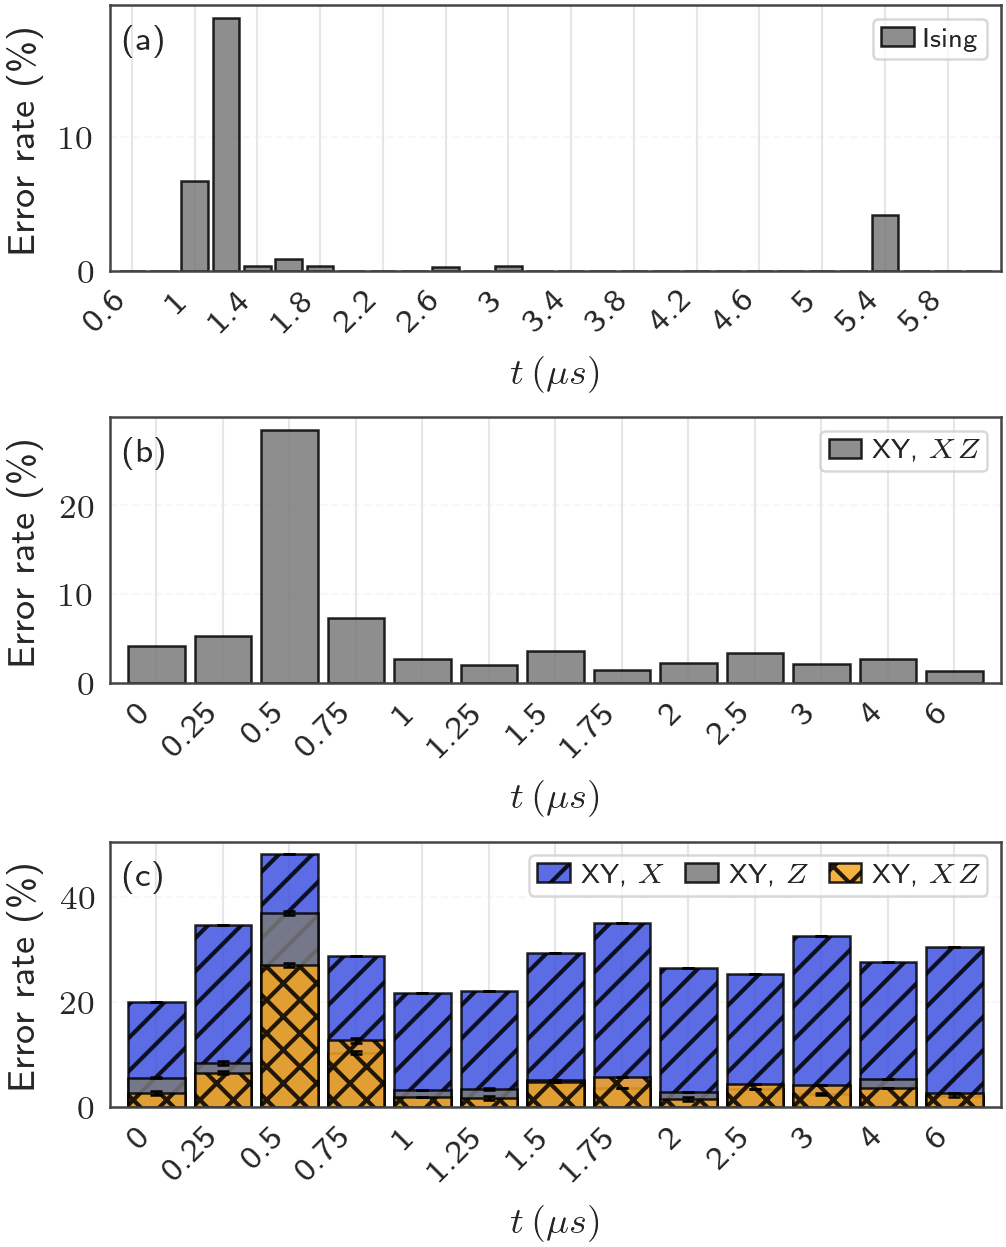

In [15]:
# One style per model. The hatches are what keep the layered panels readable in greyscale
# and when two series nearly coincide. Panel (b) (unmatched) reuses panel (c)'s per-basis
# style so a bar can be compared straight down the column.
_XY_STYLE = {
    "z":  dict(color=COLORS["gray"], edgecolor="black"),
    "x":  dict(color=COLORS["blue"], edgecolor="black", hatch="///"),
    "xz": dict(color=COLORS["orange"], edgecolor="black", hatch="xxx"),
}
STYLE = {
    "ising":    dict(color=COLORS["gray"], edgecolor="black"),
    "xy_z":     _XY_STYLE["z"],  "xy_z_um":  _XY_STYLE["z"],
    "xy_x":     _XY_STYLE["x"],  "xy_x_um":  _XY_STYLE["x"],
    "xy_xz":    _XY_STYLE["xz"], "xy_xz_um": _XY_STYLE["z"],
}

# Error-bar look, shared by every bar drawn below -- thin enough not to compete with
# the bars themselves at this figure size.
EBAR_KW = dict(elinewidth=0.6, capsize=1.5, capthick=0.6, ecolor="black")

# "%" is a comment character under usetex, so it must be escaped there and must NOT be
# escaped when the mathtext fallback is in force.
_PCT = r"\%" if plt.rcParams["text.usetex"] else "%"
Y_LABEL = {"percent": rf"Error rate ({_PCT})",
           "fraction": "Error rate",
           "count": "Errors"}


def series(k, mode):
    """One model's mean bar heights. `nan` (no samples at that time) becomes 0 for drawing.

    The count is recovered as rate x n rather than counted separately, so the two modes
    cannot drift apart: they are literally the same numbers with one factor between them.
    """
    e = np.nan_to_num(ERR[k])
    return {"percent": 100 * e, "fraction": e, "count": e * CNT[k]}[mode]


def series_err(k, mode):
    """The +/- std-across-seeds error bar for one model, in `series()`'s units.

    None for a model with only one seed: `ERR_SD[k]` is all-nan by construction
    (`error_stats_by_time` skips the std computation outright rather than let it
    happen to come back nan/0 from `nanstd` on a single sample). `ax.bar(...,
    yerr=None)` then simply draws no error bars, which is the honest picture -- a
    drawn "+/-0" bar would visually claim a certainty a single seed doesn't have.
    """
    if np.all(np.isnan(ERR_SD[k])):
        return None
    e = np.nan_to_num(ERR_SD[k])
    return {"percent": 100 * e, "fraction": e, "count": e * CNT[k]}[mode]


def _draw(ax, keys, all_times, style, mode):
    x = np.arange(len(all_times))
    hidden = []
    if style == "dodged":
        w = 0.85 / len(keys)
        for i, k in enumerate(keys):
            off = (i - (len(keys) - 1) / 2) * w
            ax.bar(x + off, series(k, mode), w, yerr=series_err(k, mode),
                   error_kw=EBAR_KW, label=MODELS[k]["label"], **STYLE[k])
    else:
        # Tallest series behind, so the smaller ones stay visible in front of it. The
        # ordering is by the DRAWN heights, so it follows `mode` -- switching to counts
        # can reorder the series, since a low rate on a well-sampled time point can be
        # more errors than a high rate on a sparse one.
        order = sorted(keys, key=lambda k: -series(k, mode).sum())
        for k in order:
            ax.bar(x, series(k, mode), 0.85, yerr=series_err(k, mode), error_kw=EBAR_KW,
                   label=MODELS[k]["label"], **STYLE[k], alpha=0.85)
        for front, back in zip(order[1:], order[:-1]):
            # A real occlusion only where BOTH series actually have a bar -- a time
            # point the front series' grid does not reach (panel (b): X/XZ against
            # unmatched Z's 21-point grid) is a gap, not something hidden.
            both = ~np.isnan(ERR[front]) & ~np.isnan(ERR[back])
            n = int((both & (series(front, mode) > series(back, mode) + 1e-12)).sum())
            if n:
                hidden.append((MODELS[front]["label"], MODELS[back]["label"], n))
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_xlim(-0.7, len(all_times) - 0.3)
    return x, hidden


def _ticks(ax, x, all_times, max_labels=16):
    """Label every nth bar, so a 21/28-point grid does not overlap itself into a smear."""
    every = max(1, int(np.ceil(len(all_times) / max_labels)))
    ax.set_xticks(x, minor=every > 1)
    if every > 1:
        ax.set_xticks(x[::every])
    ax.set_xticklabels([f"{t / 1000:g}" for t in all_times[::every]],
                       rotation=45, ha="right")


# (panel letter, the models on it, its time grid, a short subtitle)
PANELS = [("a", list(TOP), TOP_TIMES, ""),
          ("b", list(MIDDLE), MIDDLE_TIMES, ""),
          ("c", list(BOTTOM), BOTTOM_TIMES, "")]
        #   ("b", list(MIDDLE), MIDDLE_TIMES, " unmatched"),
        #   ("c", list(BOTTOM), BOTTOM_TIMES, " matched")]


def plot_error_rates(style=None, mode=None, save=True):
    style = XY_PANEL_STYLE if style is None else style
    mode = Y_MODE if mode is None else mode
    if mode not in Y_LABEL:
        raise ValueError(f"mode must be one of {sorted(Y_LABEL)}, got {mode!r}")

    fig, axes = plt.subplots(
        # 3, 1, figsize=(SINGLE_WIDTH, 2.5 * SINGLE_WIDTH / GOLDEN))
        3, 1, figsize=(SINGLE_WIDTH, 2 * SINGLE_WIDTH / GOLDEN))
    try:
        fig.set_constrained_layout_pads(hspace=0.06)
    except AttributeError:
        fig.subplots_adjust(hspace=0.6)

    all_hidden = []
    for ax, (tag, keys, times, sub) in zip(axes, PANELS):
        # Panel (a) has one series; the layered/dodged distinction is moot, so it is
        # always drawn layered. The two XY panels follow XY_PANEL_STYLE.
        pstyle = "layered" if tag == "a" else style
        xk, hid = _draw(ax, keys, times, pstyle, mode)
        all_hidden += hid
        ax.set_ylabel(Y_LABEL[mode])
        ax.text(0.015, 0.93, f"({tag}){sub}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8)
        _ticks(ax, xk, times)
        ax.set_xlabel(r"$t\,(\mu s)$")

    axes[0].legend(fontsize=6.5, handletextpad=0.4, borderpad=0.3, loc="upper right")
    for ax in (axes[1], axes[2]):        # same 3 labels on both XY panels
        ax.legend(fontsize=6.5, handletextpad=0.4, borderpad=0.3, ncol=3,
                  columnspacing=0.8, loc="upper right")

    # The count panel must sum to the (mean-over-seeds) total error count printed with
    # the table; a tolerance rather than exact equality since that total is itself an
    # average of 5 integers and need not be a whole number.
    if mode == "count":
        for k in MODELS:
            drawn = float(series(k, "count").sum())
            actual_mean = float(np.mean(
                [int((d["y_pred"] != d["y_true"]).sum()) for d in DATA[k]]))
            assert abs(drawn - actual_mean) < 1.0, (
                f"{k}: bars sum to {drawn}, mean model errors {actual_mean}")

    for front, back, n in all_hidden:
        print(f"  note: {front} exceeds {back} at {n} time point(s), where the "
              f"{back} bar is hidden behind it")

    if save:
        out = OUTDIR / f"model_error_{mode}_{SPLIT}.pdf"
        fig.savefig(out, bbox_inches="tight")
        print(f"wrote {out}")
    return fig, axes


fig, axes = plot_error_rates()
plt.show()

In [16]:
fig.savefig(OUTDIR / f"model_error_rates_{SPLIT}.pdf", dpi=300)

### The same figure in absolute counts

`Y_MODE = "count"`: same call, same grouping, `mode` switched. This is the panel that
reconciles the rates above with the overall accuracies printed at load time.

The rate panel and the count panel disagree about which bar is the tall one, and that
disagreement is the point. A time point contributing 90 snapshots and one contributing
330 look identical on a rate axis; on a count axis the sparse one shrinks to what it
actually is. Read the rate panel to ask *where the model is unreliable* and the count
panel to ask *where its mistakes actually are*, for the Ising run those are different
time points.

The counts are asserted to reproduce the model's mean total error count (within
rounding), so the two panels cannot silently disagree about the same runs.

wrote Plots/model_error_count_val.pdf


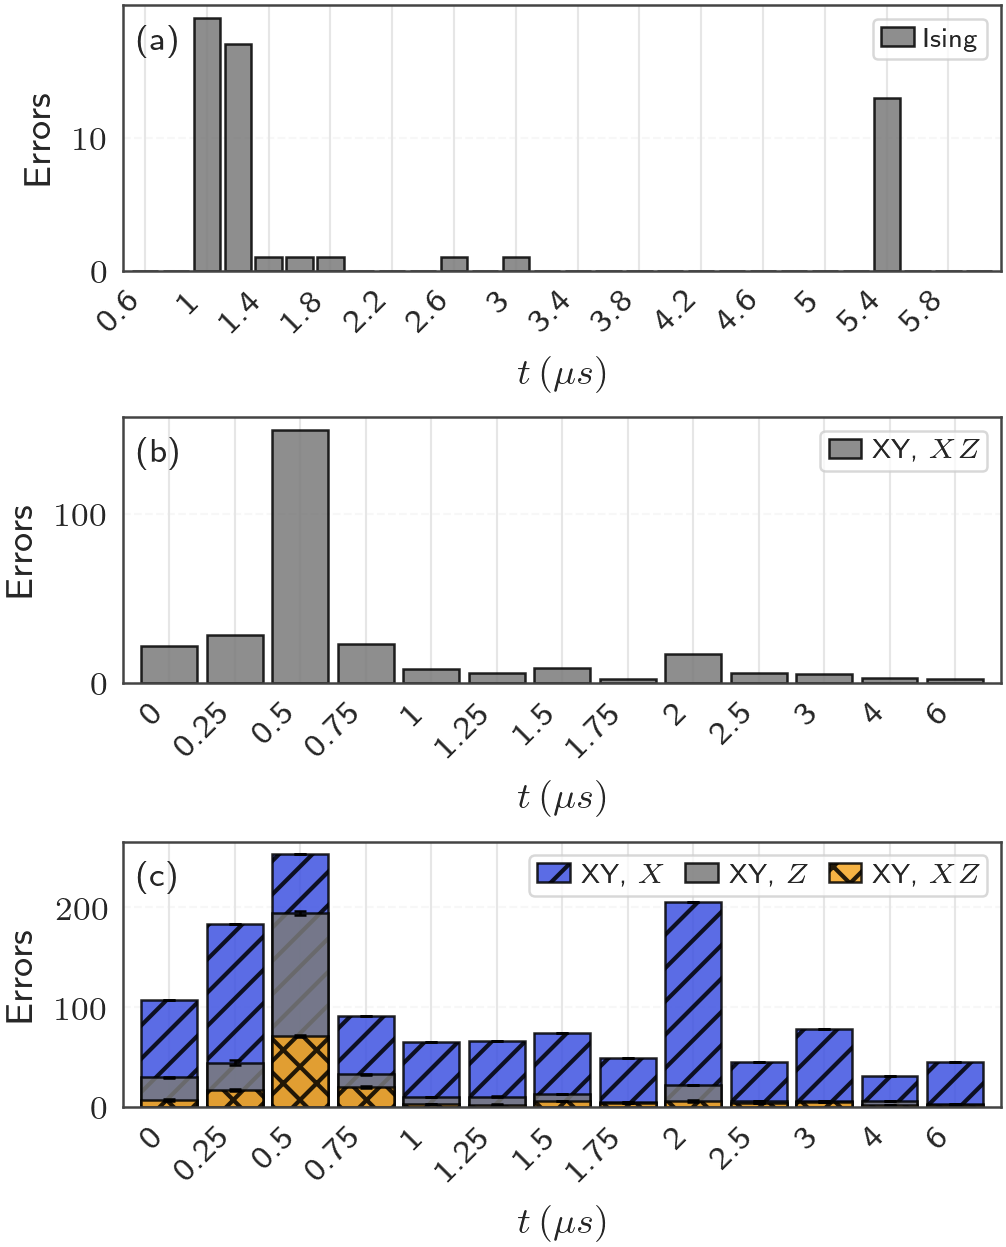


 panel     model   errors       n     rate   worst rate (mean+/-sd) / worst count
     a     ising       54    6282   0.0086   t=1.2us 18.9+-nan% (17/90)  /  t=1us 19 errors (6.7+-nan%)
     b  xy_xz_um      281    4347   0.0646   t=0.5us 28.5+-nan% (150/526)  /  t=0.5us 150 errors (28.5+-nan%)
     c      xy_z      383    4347   0.0881   t=0.5us 36.9+-0.4% (194/526)  /  t=0.5us 194 errors (36.9+-0.4%)
     c      xy_x     1292    4347   0.2972   t=0.5us 48.1+-0.0% (253/526)  /  t=0.5us 253 errors (48.1+-0.0%)
     c     xy_xz      151    2176   0.0694   t=0.5us 27.1+-0.3% (71/263)  /  t=0.5us 71 errors (27.1+-0.3%)


In [17]:
fig_n, axes_n = plot_error_rates(mode="count")
plt.show()

# Per-panel totals, so each bar can be checked against the column it came from.
print(f"\n{'panel':>6}{'model':>10}{'errors':>9}{'n':>8}{'rate':>9}"
      f"   worst rate (mean+/-sd) / worst count")
for k in MODELS:
    all_t = PANEL_TIMES[k]
    rate, sd, cnt = ERR[k], ERR_SD[k], series(k, "count")
    i_rate = int(np.nanargmax(rate))
    i_cnt = int(np.argmax(cnt))
    n_err = int(round(cnt.sum()))
    print(f"{PANEL_OF[k]:>6}{k:>10}{n_err:>9}{int(CNT[k].sum()):>8}"
          f"{n_err / CNT[k].sum():>9.4f}   "
          f"t={all_t[i_rate] / 1000:g}us {100 * rate[i_rate]:.1f}+-{100 * sd[i_rate]:.1f}% "
          f"({int(round(cnt[i_rate]))}/{CNT[k][i_rate]})  /  "
          f"t={all_t[i_cnt] / 1000:g}us {int(round(cnt[i_cnt]))} errors "
          f"({100 * rate[i_cnt]:.1f}+-{100 * sd[i_cnt]:.1f}%)")

In [18]:
fig_n.savefig(OUTDIR / f"model_error_counts_{SPLIT}.pdf", dpi=300)

## Provenance

Everything quotable from the figure, traced back to the runs that produced it: every
one of the 5 seeds behind each bar, plus the mean ± std that bar actually shows.

In [19]:
print(f"split          : {SPLIT}")
print(f"panel style    : {XY_PANEL_STYLE}")
print(f"XZ_SNAPSHOTS    : {XZ_SNAPSHOTS}  (panel (c) XZ bar only)\n")

hdr = (f"{'panel':>6} {'model':>9} {'dataset':>14} {'lam':>4} {'part':>5} {'seed':>6} "
       f"{'n':>7} {'err':>8}  run")
print(hdr); print("-" * len(hdr))
for k, m in MODELS.items():
    panel = PANEL_OF[k]
    errs = []
    for s, d in zip(m["seeds"], DATA[k]):
        err = float((d["y_pred"] != d["y_true"]).mean())
        errs.append(err)
        print(f"{panel:>6} {k:>9} {d['cf'].dataset:>14} {d['cf'].lam:>4} "
              f"{d['cf'].partition_index:>5} {s:>6} "
              f"{len(d['y_true']):>7} {err:>8.4f}  {seed_path(m, s)}")
    errs = np.array(errs)
    n_seeds = len(errs)
    if n_seeds > 1:
        print(f"{panel:>6} {k:>9} {'':>14} {'':>4} {'':>5} {'mean':>6} "
              f"{'':>7} {errs.mean():>8.4f}  +/- {errs.std(ddof=1):.4f}  ({n_seeds} seeds)")
    else:
        # One seed -> no mean/std to report; the single row above already IS the number.
        print(f"{panel:>6} {k:>9} {'':>14} {'':>4} {'':>5} {'':>6} "
              f"{'':>7} {'':>8}  ({n_seeds} seed)")

split          : val
panel style    : layered
XZ_SNAPSHOTS    : half  (panel (c) XZ bar only)

 panel     model        dataset  lam  part   seed       n      err  run
-----------------------------------------------------------------------
     a     ising    Paris_Ising    3     2     42    6282   0.0086  Plots_data/Ising_C4_smallkernels_lam3_seed42_p2
     a     ising                                                    (1 seed)
     b  xy_xz_um    Paris_XY_XZ    3     2     46    4347   0.0646  Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
     b  xy_xz_um                                                    (1 seed)
     c      xy_z     Paris_XY_Z    3     2     42    4347   0.0888  Plots_data/XY_Z_C4_smallkernels_lam3_seed42_p2_matched
     c      xy_z     Paris_XY_Z    3     2     43    4347   0.0867  Plots_data/XY_Z_C4_smallkernels_lam3_seed43_p2_matched
     c      xy_z     Paris_XY_Z    3     2     44    4347   0.0883  Plots_data/XY_Z_C4_smallkernels_lam3_seed44_p2_matched
     c